<a href="https://colab.research.google.com/github/Puja528/KonflikJadwal_Kel11/blob/main/StatistikaDeskriptif_KonflikJadwal_Kel11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistika Deskriptif Konflik Jadwal Perkuliahan

**Projek Statistika dan Probabilitas – Penyajian Data dan Statistika Deskriptif dengan Python**

- **A. Pengorganisasian data**: membaca data dan membuat tabel frekuensi
- **B. Penyajian data**: grafik garis, batang, dan pie
- **C. Statistika deskriptif**: ukuran pemusatan, penyebaran, bentuk distribusi, dan outlier (1,5 × IQR)
- **D. Ringkasan konflik**: sebaran sesi bentrok menurut hari, semester akademik, prodi, dan ruangan

Unit observasi: satu sesi kuliah. Variabel utama: `Status_Konflik`, `Jumlah_Sesi_Ruangan_Per_Hari`, `Durasi_Sesi`.

## A. Pengorganisasian Data

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Jika dijalankan di Google Colab dan file belum ada, unggah dulu file dataset
path = '3TIB_11_DatasetPenjadwalan.xlsx'
if not os.path.exists(path):
    from google.colab import files
    files.upload()

# Tabel Data
dataraw = pd.read_excel(path, sheet_name='Dataset')
print(dataraw.shape)
dataraw.head(10)

(4557, 14)


,ID_Sesi,Semester_Akademik,Hari,Program_Studi,Semester_Kelas,Kelas,Mata_Kuliah,Kode_Dosen,Ruangan,Jam_Mulai,Durasi_Sesi,Jumlah_Dosen,Jumlah_Sesi_Ruangan_Per_Hari,Status_Konflik
0,1,Ganjil 2023/2024,Senin,AKTP,1,A,Kewirausahaan,LUS,128,7.0,2.0,1,3,0
1,2,Ganjil 2023/2024,Senin,AKTP,1,B,Pancasila,AST,127,7.0,2.0,1,4,0
2,3,Ganjil 2023/2024,Senin,AKTP,2,B,Akuntansi Keuangan Menengah I,HMD,151,7.0,3.0,1,3,0
3,4,Ganjil 2023/2024,Senin,AKTP,4,A,Praktikum Akuntansi Pemerintahan,FIA/OSY,351,7.0,3.0,2,1,0
4,5,Ganjil 2023/2024,Senin,AKTP,4,B,Praktikum Akuntansi Perpajakan,TAF/ABB,251,7.0,3.0,2,3,0
5,6,Ganjil 2023/2024,Senin,MS,1,B,Workshop Teknologi Mekanik 1,HKO/ADY/PUT,WS MD,7.0,7.0,3,1,0
6,7,Ganjil 2023/2024,Senin,MS,2,A,Praktikum Pengelasan Lanjut,JUP/DSD,WS Las Lanjut,7.0,6.0,2,1,0
7,8,Ganjil 2023/2024,Senin,MS,2,B,Workshop Destructive Test (DT),NCN/DNR,WS PPT,7.0,6.0,2,1,0
8,9,Ganjil 2023/2024,Senin,MS,3,A,Metrologi Industri dan Kontrol Kualitas Geometri,EDL,153,7.0,3.0,1,3,0
9,10,Ganjil 2023/2024,Senin,MS,3,B,Mesin Pemindah Bahan,RNS,353,7.0,3.0,1,2,0


In [2]:
# Struktur data dan pemeriksaan missing value
dataraw.info()
print('\nTotal missing value:', int(dataraw.isna().sum().sum()))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4557 entries, 0 to 4556
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID_Sesi                       4557 non-null   int64  
 1   Semester_Akademik             4557 non-null   object 
 2   Hari                          4557 non-null   object 
 3   Program_Studi                 4557 non-null   object 
 4   Semester_Kelas                4557 non-null   int64  
 5   Kelas                         4557 non-null   object 
 6   Mata_Kuliah                   4557 non-null   object 
 7   Kode_Dosen                    4557 non-null   object 
 8   Ruangan                       4557 non-null   object 
 9   Jam_Mulai                     4557 non-null   float64
 10  Durasi_Sesi                   4557 non-null   float64
 11  Jumlah_Dosen                  4557 non-null   int64  
 12  Jumlah_Sesi_Ruangan_Per_Hari  4557 non-null   int64  
 13  Sta

In [3]:
# Tabel Frekuensi Status Konflik (crosstab seperti contoh dosen)
datafrq = pd.crosstab(index=dataraw['Status_Konflik'], columns='Frekuensi')
datafrq['Persentase (%)'] = (datafrq['Frekuensi'] / datafrq['Frekuensi'].sum() * 100).round(2)
datafrq.index = ['0 = Tidak bentrok', '1 = Bentrok']
datafrq.columns.name = None
datafrq.loc['Total'] = [datafrq['Frekuensi'].sum(), 100.0]
datafrq

,Frekuensi,Persentase (%)
0 = Tidak bentrok,4436.0,97.34
1 = Bentrok,121.0,2.66
Total,4557.0,100.00


In [4]:
def tabel_frekuensi(kolom, urut=None):
    t = pd.crosstab(index=dataraw[kolom], columns='Frekuensi')
    t.columns.name = None
    if urut is not None:
        t = t.reindex([u for u in urut if u in t.index])
    t['Persentase (%)'] = (t['Frekuensi'] / t['Frekuensi'].sum() * 100).round(2)
    t.loc['Total'] = [t['Frekuensi'].sum(), round(t['Persentase (%)'].sum())]
    return t

urut_hari = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu']
urut_sem = ['Ganjil 2023/2024', 'Genap 2023/2024', 'Ganjil 2024/2025', 'Genap 2024/2025',
            'Ganjil 2025/2026', 'Genap 2025/2026', 'Ganjil 2026/2027']

print('Frekuensi sesi menurut HARI');               display(tabel_frekuensi('Hari', urut_hari))
print('Frekuensi sesi menurut SEMESTER AKADEMIK');  display(tabel_frekuensi('Semester_Akademik', urut_sem))
print('Frekuensi sesi menurut DURASI SESI (jam)');  display(tabel_frekuensi('Durasi_Sesi'))
print('Frekuensi sesi menurut JUMLAH DOSEN');       display(tabel_frekuensi('Jumlah_Dosen'))
print('Frekuensi sesi menurut SEMESTER KELAS');     display(tabel_frekuensi('Semester_Kelas'))
print('Frekuensi sesi menurut PROGRAM STUDI');      display(tabel_frekuensi('Program_Studi').sort_values('Frekuensi', ascending=False))

Frekuensi sesi menurut HARI


,Frekuensi,Persentase (%)
Hari,,
Senin,915,20.08
Selasa,928,20.36
Rabu,1015,22.27
Kamis,939,20.61
Jumat,745,16.35
Sabtu,15,0.33
Total,4557,100.00


Frekuensi sesi menurut SEMESTER AKADEMIK


,Frekuensi,Persentase (%)
Semester_Akademik,,
Ganjil 2023/2024,663,14.55
Genap 2023/2024,487,10.69
Ganjil 2024/2025,735,16.13
Genap 2024/2025,635,13.93
Ganjil 2025/2026,698,15.32
Genap 2025/2026,667,14.64
Ganjil 2026/2027,672,14.75
Total,4557,100.00


Frekuensi sesi menurut DURASI SESI (jam)


...

,Frekuensi,Persentase (%)
Jumlah_Dosen,,
1,2471,54.22
2,2002,43.93
3,82,1.80
4,2,0.04
Total,4557,100.00


Frekuensi sesi menurut SEMESTER KELAS


,Frekuensi,Persentase (%)
Semester_Kelas,,
1,1819,39.92
2,1715,37.63
3,752,16.50
4,271,5.95
Total,4557,100.00


Frekuensi sesi menurut PROGRAM STUDI


,Frekuensi,Persentase (%)
Program_Studi,,
Total,4557,100.00
TI,1173,25.74
SI,655,14.37
AKTP,432,9.48
TRM,336,7.37
TRK,316,6.93
TRSE,289,6.34
TMS,282,6.19
TL,272,5.97


## B. Penyajian Data

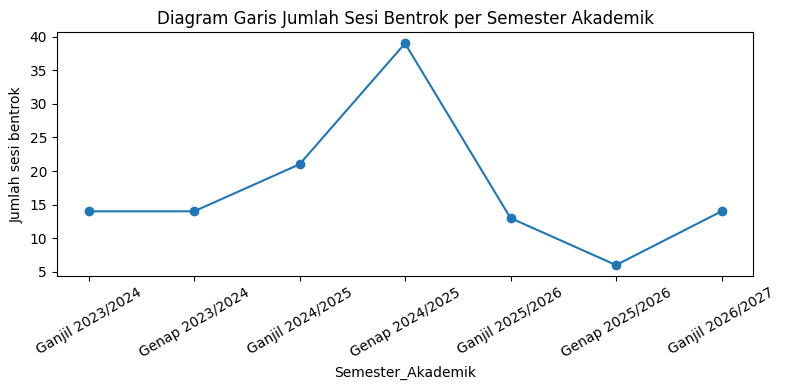

Semester_Akademik
Ganjil 2023/2024    14
Genap 2023/2024     14
Ganjil 2024/2025    21
Genap 2024/2025     39
Ganjil 2025/2026    13
Genap 2025/2026      6
Ganjil 2026/2027    14
dtype: int64

In [ ]:
# Grafik Garis: jumlah sesi bentrok pada tiap semester akademik
bentrok_sem = (dataraw[dataraw['Status_Konflik'] == 1]
               .groupby('Semester_Akademik').size().reindex(urut_sem))
bentrok_sem.plot(marker='o', figsize=(8, 4), title='Diagram Garis Jumlah Sesi Bentrok per Semester Akademik')
plt.ylabel('Jumlah sesi bentrok'); plt.xticks(rotation=30); plt.tight_layout(); plt.show()
bentrok_sem

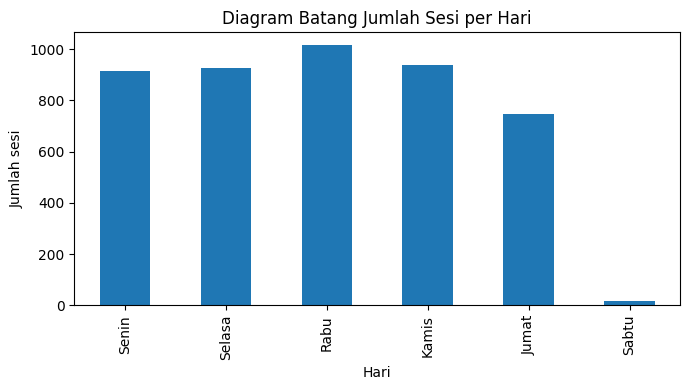

In [ ]:
# Grafik Batang: jumlah sesi per hari
frek_hari = tabel_frekuensi('Hari', urut_hari).drop(index='Total')
frek_hari['Frekuensi'].plot(kind='bar', figsize=(7, 4), title='Diagram Batang Jumlah Sesi per Hari')
plt.ylabel('Jumlah sesi'); plt.tight_layout(); plt.show()

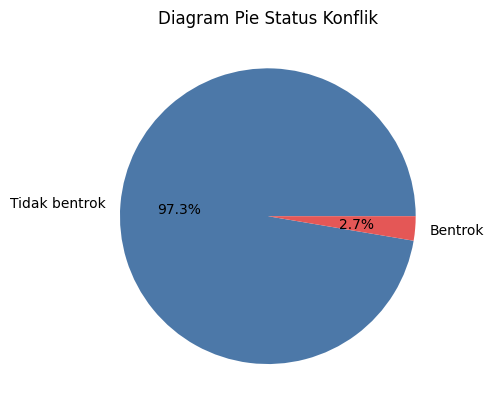

In [ ]:
# Pie Chart: status konflik
dataraw['Status_Konflik'].value_counts().sort_index().plot(
    kind='pie', labels=['Tidak bentrok', 'Bentrok'], autopct='%1.1f%%', figsize=(5, 5),
    colors=['#4C78A8', '#E45756'], title='Diagram Pie Status Konflik')
plt.ylabel(''); plt.tight_layout(); plt.show()

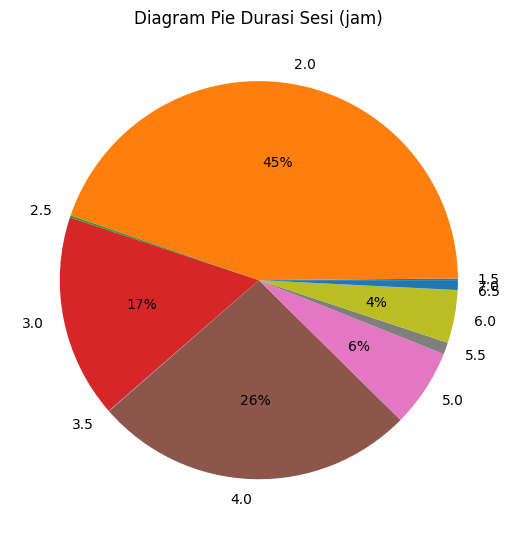

In [ ]:
# Pie Chart: komposisi durasi sesi
dataraw['Durasi_Sesi'].value_counts().sort_index().plot(
    kind='pie', autopct=lambda p: f'{p:.0f}%' if p >= 3 else '', figsize=(5.5, 5.5),
    title='Diagram Pie Durasi Sesi (jam)')
plt.ylabel(''); plt.tight_layout(); plt.show()

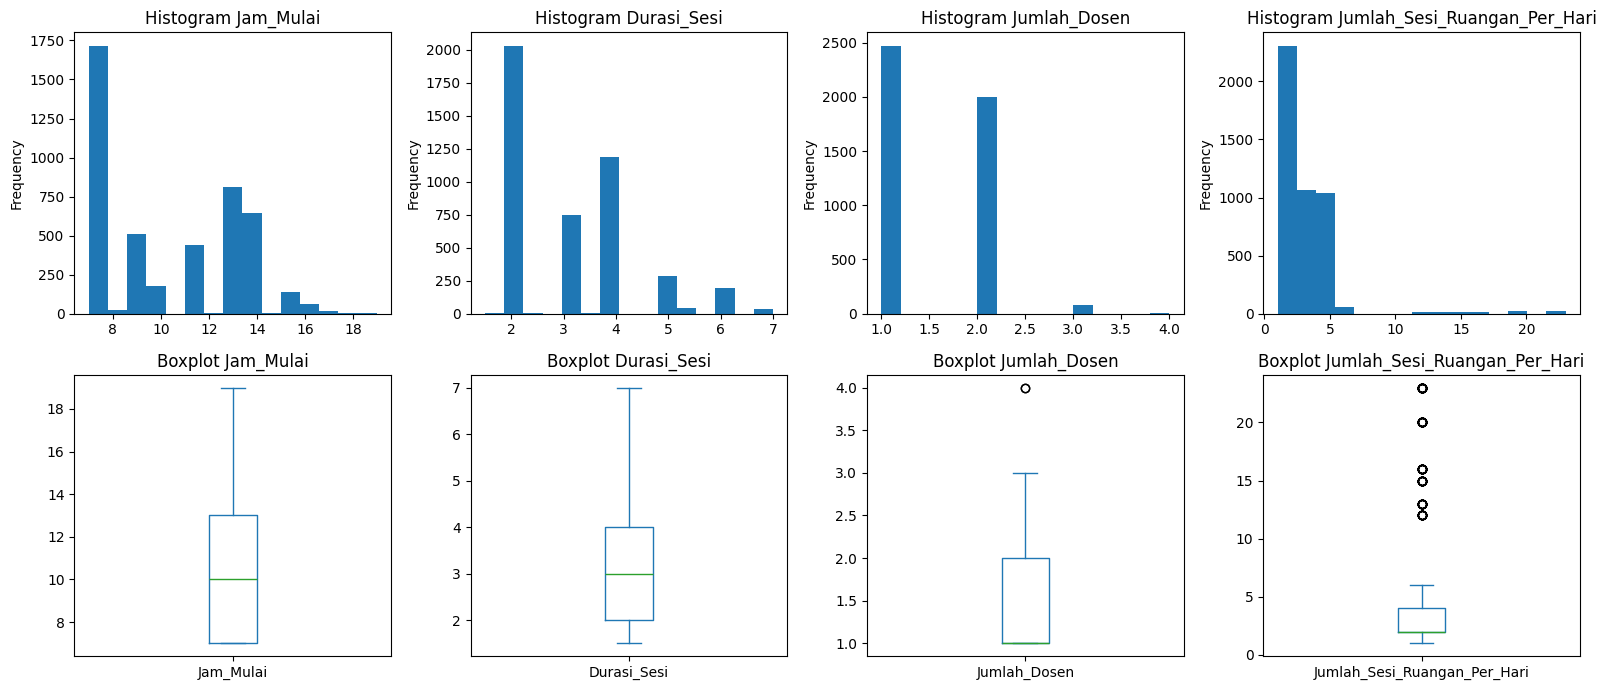

In [ ]:
# Histogram dan boxplot variabel numerik
num_cols = ['Jam_Mulai', 'Durasi_Sesi', 'Jumlah_Dosen', 'Jumlah_Sesi_Ruangan_Per_Hari']
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, c in enumerate(num_cols):
    dataraw[c].plot(kind='hist', bins=15, ax=axes[0, i], title=f'Histogram {c}')
    dataraw[c].plot(kind='box', ax=axes[1, i], title=f'Boxplot {c}')
plt.tight_layout(); plt.show()

## C. Statistika Deskriptif

In [ ]:
# Statistik deskriptif lengkap (mengikuti kode contoh dosen, ditambah IQR, CV, dan outlier)
def statistik(s):
    s = pd.to_numeric(s, errors='coerce').dropna()
    stats = s.describe()
    stats['Standard Error'] = s.sem()
    stats['Median'] = s.median()
    stats['Mode'] = s.mode().iloc[0]
    stats['variance'] = s.var()
    stats['range'] = s.max() - s.min()
    stats['skewness'] = s.skew()
    stats['kurtosis'] = s.kurtosis()      # excess kurtosis (normal = 0)
    stats['IQR'] = stats['75%'] - stats['25%']
    stats['CV (%)'] = s.std() / s.mean() * 100
    stats['batas bawah'] = stats['25%'] - 1.5 * stats['IQR']
    stats['batas atas'] = stats['75%'] + 1.5 * stats['IQR']
    stats['jumlah outlier'] = int(((s < stats['batas bawah']) | (s > stats['batas atas'])).sum())
    return stats

hasil = pd.DataFrame({c: statistik(dataraw[c]) for c in num_cols})
hasil.round(3)

,Jam_Mulai,Durasi_Sesi,Jumlah_Dosen,Jumlah_Sesi_Ruangan_Per_Hari
count,4557.000,4557.000,4557.000,4557.000
mean,10.204,3.125,1.477,2.989
std,2.977,1.235,0.537,2.504
min,7.000,1.500,1.000,1.000
25%,7.000,2.000,1.000,2.000
50%,10.000,3.000,1.000,2.000
75%,13.000,4.000,2.000,4.000
max,19.000,7.000,4.000,23.000
Standard Error,0.044,0.018,0.008,0.037
Median,10.000,3.000,1.000,2.000


In [ ]:
# Statistik deskriptif per variabel, dipisahkan menurut status konflik
pd.concat({'Tidak bentrok': dataraw[dataraw['Status_Konflik'] == 0][num_cols].describe().T,
           'Bentrok': dataraw[dataraw['Status_Konflik'] == 1][num_cols].describe().T}, axis=1).round(2)

Tidak bentrok                                     \
                                     count   mean   std  min  25%   50%   75%   
Jam_Mulai                           4436.0  10.23  2.99  7.0  7.0  10.0  13.0   
Durasi_Sesi                         4436.0   3.11  1.22  1.5  2.0   3.0   4.0   
Jumlah_Dosen                        4436.0   1.47  0.54  1.0  1.0   1.0   2.0   
Jumlah_Sesi_Ruangan_Per_Hari        4436.0   3.00  2.53  1.0  2.0   2.0   4.0   

                                   Bentrok                                   \
                               max   count  mean   std  min  25%  50%   75%   
Jam_Mulai                     19.0   121.0  9.36  2.42  7.0  7.0  9.0  11.0   
Durasi_Sesi                    7.0   121.0  3.70  1.58  2.0  2.0  4.0   5.0   
Jumlah_Dosen                   4.0   121.0  1.65  0.57  1.0  1.0  2.0   2.0   
Jumlah_Sesi_Ruangan_Per_Hari  23.0   121.0  2.63  1.33  1.0  2.0  2.0   3.0   

                                    
                               max  
Jam_Mulai                     15.0  
Durasi_Sesi                    7.0  
Jumlah_Dosen                   3.0  
Jumlah_Sesi_Ruangan_Per_Hari   6.0

In [ ]:
# Interpretasi otomatis berdasarkan acuan praktis dosen
def interpretasi(nama, st):
    print(f'=== {nama} ===')
    sel = abs(st['mean'] - st['Median'])
    arah = ('Mean > Median: cenderung miring ke kanan' if st['mean'] > st['Median'] + 1e-9
            else 'Mean < Median: cenderung miring ke kiri' if st['mean'] < st['Median'] - 1e-9
            else 'Mean = Median: simetris')
    print(f"Pemusatan  : mean {st['mean']:.2f}, median {st['Median']:.2f}, modus {st['Mode']:.2f} -> {arah}")
    print(f"Penyebaran : min {st['min']:.2f}, max {st['max']:.2f}, range {st['range']:.2f}, "
          f"SD {st['std']:.2f}, CV {st['CV (%)']:.1f}%, IQR {st['IQR']:.2f}")
    sk = st['skewness']
    k_sk = ('sangat mendekati simetris' if abs(sk) <= 0.5 else 'cukup dekat simetris' if abs(sk) <= 1
            else 'dapat ditoleransi' if abs(sk) <= 2 else 'kemencengan kuat')
    print(f"Skewness   : {sk:.3f} -> {k_sk}")
    ku = st['kurtosis']
    k_ku = ('mendekati normal' if abs(ku) <= 1 else 'masih dapat diterima' if abs(ku) <= 2
            else 'lebih runcing/berekor berat' if ku > 2 else 'lebih datar')
    print(f"Kurtosis   : {ku:.3f} -> {k_ku}")
    print(f"Outlier    : {int(st['jumlah outlier'])} data di luar [{st['batas bawah']:.2f}, {st['batas atas']:.2f}]")
    print(f"Std. error : {st['Standard Error']:.4f}\n")

for c in num_cols:
    interpretasi(c, hasil[c])

=== Jam_Mulai ===
Pemusatan  : mean 10.20, median 10.00, modus 7.00 -> Mean > Median: cenderung miring ke kanan
Penyebaran : min 7.00, max 19.00, range 12.00, SD 2.98, CV 29.2%, IQR 6.00
Skewness   : 0.246 -> sangat mendekati simetris
Kurtosis   : -1.418 -> masih dapat diterima
Outlier    : 0 data di luar [-2.00, 22.00]
Std. error : 0.0441

=== Durasi_Sesi ===
Pemusatan  : mean 3.12, median 3.00, modus 2.00 -> Mean > Median: cenderung miring ke kanan
Penyebaran : min 1.50, max 7.00, range 5.50, SD 1.23, CV 39.5%, IQR 2.00
Skewness   : 0.834 -> cukup dekat simetris
Kurtosis   : -0.112 -> mendekati normal
Outlier    : 0 data di luar [-1.00, 7.00]
Std. error : 0.0183

=== Jumlah_Dosen ===
Pemusatan  : mean 1.48, median 1.00, modus 1.00 -> Mean > Median: cenderung miring ke kanan
Penyebaran : min 1.00, max 4.00, range 3.00, SD 0.54, CV 36.4%, IQR 1.00
Skewness   : 0.485 -> sangat mendekati simetris
Kurtosis   : -0.883 -> mendekati normal
Outlier    : 2 data di luar [-0.50, 3.50]
Std. error

## D. Ringkasan Sebaran Konflik

In [ ]:
def ringkas_konflik(kolom, urut=None, min_n=0):
    t = (dataraw.groupby(kolom)['Status_Konflik']
                .agg(Jumlah_Sesi='count', Sesi_Bentrok='sum', Proporsi_Bentrok_Persen='mean'))
    t['Proporsi_Bentrok_Persen'] = (t['Proporsi_Bentrok_Persen'] * 100).round(2)
    t = t[t['Jumlah_Sesi'] >= min_n]
    if urut is not None:
        t = t.reindex([u for u in urut if u in t.index])
    return t

print('Menurut HARI');               display(ringkas_konflik('Hari', urut_hari))
print('Menurut SEMESTER AKADEMIK');  display(ringkas_konflik('Semester_Akademik', urut_sem))
print('Menurut PROGRAM STUDI (minimal 100 sesi)')
display(ringkas_konflik('Program_Studi', min_n=100).sort_values('Proporsi_Bentrok_Persen', ascending=False))
print('10 RUANGAN dengan sesi bentrok terbanyak')
display(ringkas_konflik('Ruangan').sort_values('Sesi_Bentrok', ascending=False).head(10))

Menurut HARI


,Jumlah_Sesi,Sesi_Bentrok,Proporsi_Bentrok_Persen
Hari,,,
Senin,915,29,3.17
Selasa,928,23,2.48
Rabu,1015,33,3.25
Kamis,939,25,2.66
Jumat,745,11,1.48
Sabtu,15,0,0.00


Menurut SEMESTER AKADEMIK


,Jumlah_Sesi,Sesi_Bentrok,Proporsi_Bentrok_Persen
Semester_Akademik,,,
Ganjil 2023/2024,663,14,2.11
Genap 2023/2024,487,14,2.87
Ganjil 2024/2025,735,21,2.86
Genap 2024/2025,635,39,6.14
Ganjil 2025/2026,698,13,1.86
Genap 2025/2026,667,6,0.90
Ganjil 2026/2027,672,14,2.08


Menurut PROGRAM STUDI (minimal 100 sesi)


,Jumlah_Sesi,Sesi_Bentrok,Proporsi_Bentrok_Persen
Program_Studi,,,
TMS,282,18,6.38
TRK,316,12,3.80
TET,271,10,3.69
TI,1173,33,2.81
TRJT,215,6,2.79
SI,655,17,2.60
TRM,336,7,2.08
AKTP,432,6,1.39
TL,272,3,1.10


10 RUANGAN dengan sesi bentrok terbanyak


,Jumlah_Sesi,Sesi_Bentrok,Proporsi_Bentrok_Persen
Ruangan,,,
320,56,8,14.29
283,47,6,12.77
140,95,5,5.26
WS PPT,35,5,14.29
124,144,5,3.47
128,114,4,3.51
252,53,4,7.55
361,88,4,4.55
ME 104,30,4,13.33


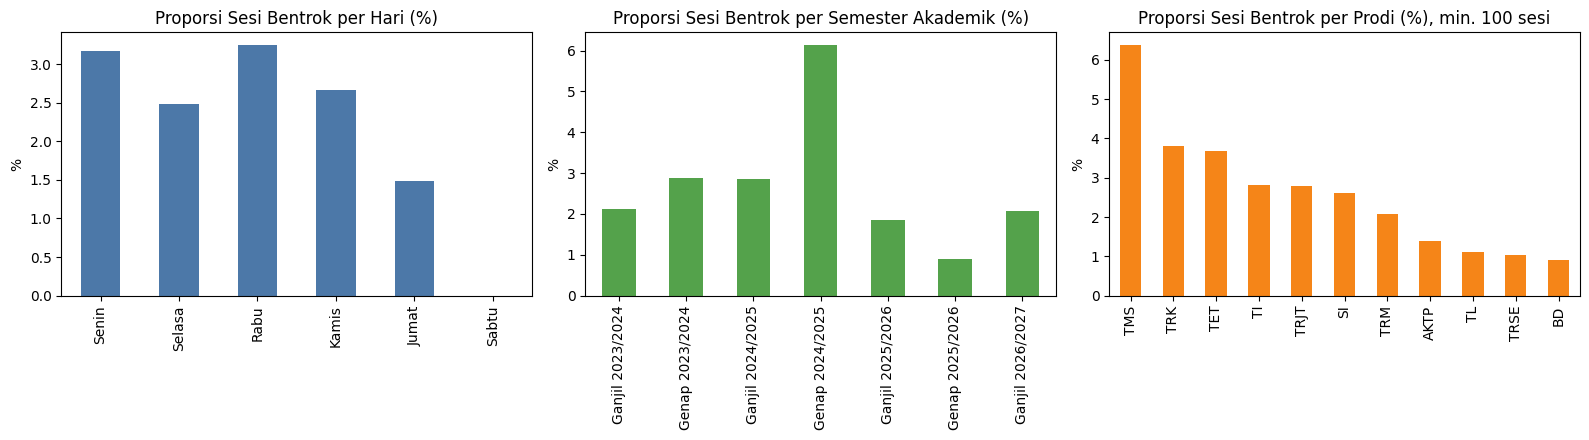

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
ringkas_konflik('Hari', urut_hari)['Proporsi_Bentrok_Persen'].plot(kind='bar', ax=axes[0], color='#4C78A8',
        title='Proporsi Sesi Bentrok per Hari (%)')
ringkas_konflik('Semester_Akademik', urut_sem)['Proporsi_Bentrok_Persen'].plot(kind='bar', ax=axes[1], color='#54A24B',
        title='Proporsi Sesi Bentrok per Semester Akademik (%)')
ringkas_konflik('Program_Studi', min_n=100).sort_values('Proporsi_Bentrok_Persen', ascending=False)[
        'Proporsi_Bentrok_Persen'].plot(kind='bar', ax=axes[2], color='#F58518',
        title='Proporsi Sesi Bentrok per Prodi (%), min. 100 sesi')
for ax in axes: ax.set_xlabel(''); ax.set_ylabel('%')
plt.tight_layout(); plt.show()

In [ ]:
print('RINGKASAN')
print('=' * 55)
n, b = len(dataraw), int(dataraw['Status_Konflik'].sum())
print(f'Jumlah sesi          : {n:,}')
print(f'Sesi bentrok         : {b:,} ({b / n * 100:.2f}%)')
h = ringkas_konflik('Hari', urut_hari, min_n=100)['Proporsi_Bentrok_Persen']
s = ringkas_konflik('Semester_Akademik', urut_sem)['Proporsi_Bentrok_Persen']
p = ringkas_konflik('Program_Studi', min_n=100)['Proporsi_Bentrok_Persen']
print(f'Hari tertinggi       : {h.idxmax()} ({h.max():.2f}%), terendah: {h.idxmin()} ({h.min():.2f}%)')
print(f'Semester tertinggi   : {s.idxmax()} ({s.max():.2f}%), terendah: {s.idxmin()} ({s.min():.2f}%)')
print(f'Prodi tertinggi      : {p.idxmax()} ({p.max():.2f}%), terendah: {p.idxmin()} ({p.min():.2f}%)')
print('Catatan: hari Sabtu hanya', int((dataraw['Hari'] == 'Sabtu').sum()), 'sesi sehingga tidak dibandingkan.')

RINGKASAN
Jumlah sesi          : 4,557
Sesi bentrok         : 121 (2.66%)
Hari tertinggi       : Rabu (3.25%), terendah: Jumat (1.48%)
Semester tertinggi   : Genap 2024/2025 (6.14%), terendah: Genap 2025/2026 (0.90%)
Prodi tertinggi      : TMS (6.38%), terendah: BD (0.90%)
Catatan: hari Sabtu hanya 15 sesi sehingga tidak dibandingkan.
